In [1]:
import pandas as pd

from jupyter_dash import JupyterDash

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

seed = 42

In [2]:
# setup dataset

def dummies(df):
    categorical_columns = df.select_dtypes(include=['category']).columns
    df_dummies = pd.DataFrame()
    for col in categorical_columns:
        dummies = pd.get_dummies(df[col], prefix=col, prefix_sep='_is_', dtype=int)
        dummies.columns = [
            f"{col}_is_{str(value).lower().replace(' ', '-').replace('_', '-')}"
            for value in dummies.columns.str.split('_is_').str[-1]
        ]
        df_dummies = pd.concat([df_dummies, dummies], axis=1)
    df = df.drop(columns=categorical_columns)
    df_final = pd.concat([df, df_dummies], axis=1)
    return df_final

def clean_feature_names(df):
    df.columns = df.columns.str.lower()
    df.columns = df.columns.str.replace(' ', '-')
    df.columns = df.columns.str.replace('_', '-')
    df.columns = df.columns.str.replace('--', '-')
    return df



sleep = pd.read_csv("data/Sleep_health_and_lifestyle_dataset.csv", index_col="Person ID")

sleep['Gender'] = sleep['Gender'].astype('category')
sleep['Age'] = sleep['Age'].astype(int)
sleep['Occupation'] = sleep['Occupation'].astype('category')
sleep['Sleep Duration'] = sleep['Sleep Duration'].astype(float)
sleep['Quality of Sleep'] = sleep['Quality of Sleep'].astype(int)
sleep['Physical Activity Level'] = sleep['Physical Activity Level'].astype(int)
sleep['Stress Level'] = sleep['Stress Level'].astype(int)
sleep['BMI Category'] = sleep['BMI Category'].astype('category')
sleep['Heart Rate'] = sleep['Heart Rate'].astype(int)
sleep['Daily Steps'] = sleep['Daily Steps'].astype(int)
sleep['Sleep Disorder'] = sleep['Sleep Disorder'].astype('category')

sleep[['systolic', 'diastolic']] = sleep['Blood Pressure'].str.split('/', expand=True)
sleep['systolic'] = sleep['systolic'].astype(int)
sleep['diastolic'] = sleep['diastolic'].astype(int)
sleep = sleep.drop(columns='Blood Pressure')

sleep = clean_feature_names(sleep)
sleep = dummies(sleep)


target = "sleep-duration"
sleep_X_reg = sleep.drop(columns=[target, 'quality-of-sleep'])

sleep_feature_names = sleep_X_reg.columns
sleep_feature_types = sleep_X_reg.dtypes

sleep_y = sleep[target]

sleep_X_train, sleep_X_test, sleep_y_train, sleep_y_test = train_test_split(sleep_X_reg, sleep_y, test_size=0.3, random_state=seed)



/home/tonso/code/00--research/eywa_trees/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tonso/code/00--research/eywa_trees/venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/tmp/ipykernel_659841/1372838307.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


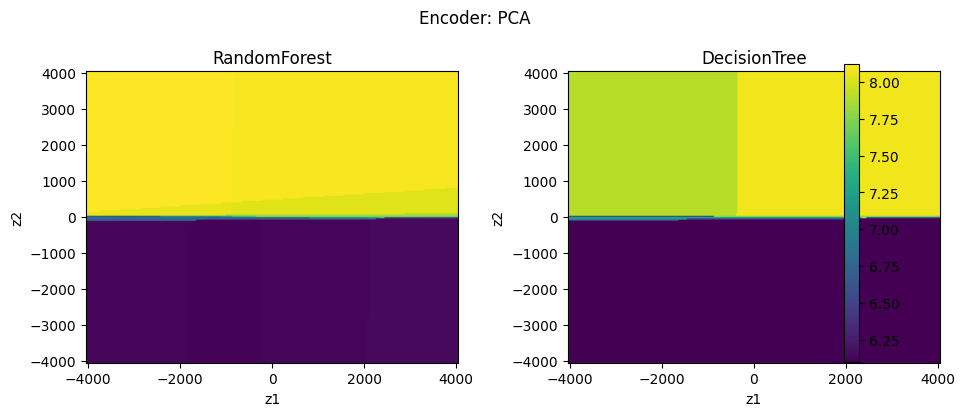

/tmp/ipykernel_659841/1372838307.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


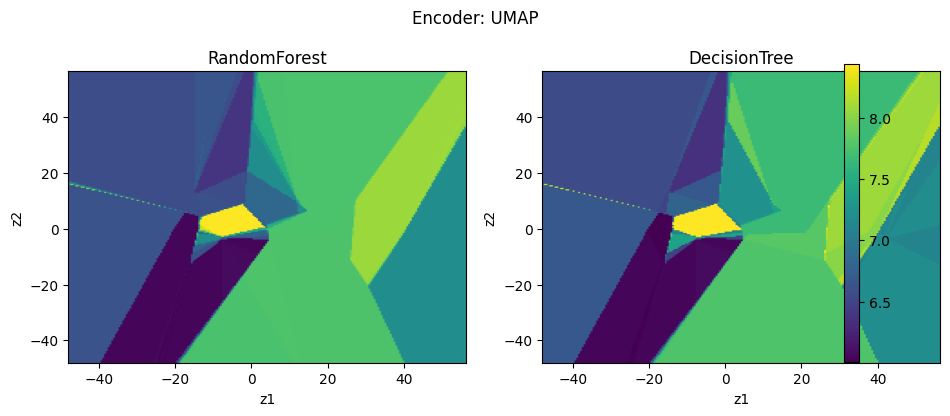

/tmp/ipykernel_659841/1372838307.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


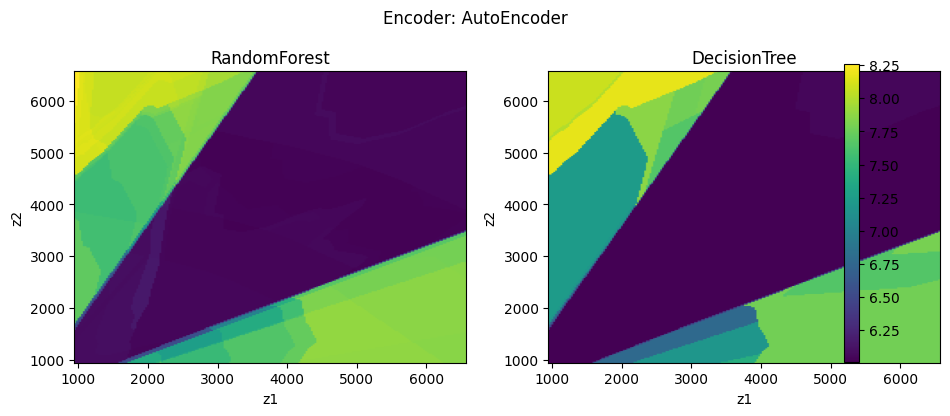

/tmp/ipykernel_659841/1372838307.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


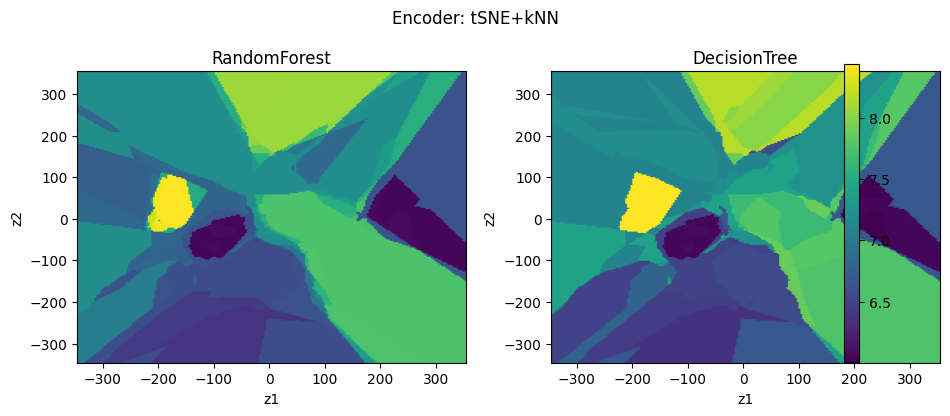

In [3]:
from dataclasses import dataclass
from typing import Callable, Tuple, List, Dict, Iterable
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import umap
import torch
import torch.nn as nn
import torch.optim as optim

Array = np.ndarray


@dataclass(frozen=True)
class VisualGridConfig:
    name:          str
    latent_dim:    int
    grid_resolution: int
    latent_bounds: Tuple[float, float]
    encode:        Callable[[Array], Array]
    decode:        Callable[[Array], Array]
    model_predict: Callable[[Array], Array]
    # convenience (for grouping/plotting)
    encoder_name:  str
    model_name:    str


def compute_grid_predictions(cfg: VisualGridConfig) -> Tuple[Array, Array]:
    coords = np.linspace(cfg.latent_bounds[0], cfg.latent_bounds[1], cfg.grid_resolution)
    mesh = np.meshgrid(*([coords] * cfg.latent_dim), indexing="xy")
    Z = np.stack(mesh, axis=-1).reshape(-1, cfg.latent_dim)
    Xg = cfg.decode(Z)
    yg = cfg.model_predict(Xg).ravel()
    return Z, yg.reshape([cfg.grid_resolution] * cfg.latent_dim)


def _imshow_extent_from_Z(Z: Array) -> Tuple[float, float, float, float]:
    xmin, xmax = Z[:, 0].min(), Z[:, 0].max()
    ymin, ymax = Z[:, 1].min(), Z[:, 1].max()
    return xmin, xmax, ymin, ymax


def plot_models_side_by_side_for_encoder(cfgs_for_encoder: List[VisualGridConfig]) -> None:
    # same grid extent and shared color scale across all models under this encoder
    Ys, Zs = [], []
    for cfg in cfgs_for_encoder:
        Z, Y = compute_grid_predictions(cfg)
        Zs.append(Z)
        Ys.append(Y)

    vmin = min(float(Y.min()) for Y in Ys)
    vmax = max(float(Y.max()) for Y in Ys)
    xmin, xmax, ymin, ymax = _imshow_extent_from_Z(Zs[0])

    n = len(cfgs_for_encoder)
    fig, axes = plt.subplots(1, n, figsize=(4.8 * n, 4.2), squeeze=False)
    axes = axes[0]
    ims = []
    for ax, cfg, Y in zip(axes, cfgs_for_encoder, Ys):
        im = ax.imshow(Y, origin="lower", extent=[xmin, xmax, ymin, ymax],
                       aspect="auto", vmin=vmin, vmax=vmax)
        ims.append(im)
        ax.set_title(cfg.model_name)
        ax.set_xlabel("z1")
        ax.set_ylabel("z2")
    cbar = fig.colorbar(ims[-1], ax=axes, fraction=0.02, pad=0.02)
    enc = cfgs_for_encoder[0].encoder_name
    fig.suptitle(f"Encoder: {enc}", fontsize=12, y=0.98)
    plt.tight_layout()
    plt.show()


class PCAEncoder:
    def __init__(self, n_components: int) -> None:
        self.pca = PCA(n_components=n_components)

    def fit(self, X: Array) -> "PCAEncoder":
        self.pca.fit(X)
        return self

    def encode(self, X: Array) -> Array:
        return self.pca.transform(X)

    def decode(self, Z: Array) -> Array:
        return self.pca.inverse_transform(Z)

    def bounds(self, Z: Array, k: float = 2.5) -> Tuple[float, float]:
        m = Z.mean(0)
        s = Z.std(0) + 1e-6
        lo = float((m - k * s).min())
        hi = float((m + k * s).max())
        return lo, hi


class UMAPEncoder:
    def __init__(self, n_components: int, n_neighbors: int = 30, min_dist: float = 0.1, random_state: int | None = None) -> None:
        self.um = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, random_state=random_state)
        self.knn: List[KNeighborsRegressor] = []

    def fit(self, X: Array) -> "UMAPEncoder":
        Z = self.um.fit_transform(X)
        self.knn = [KNeighborsRegressor(n_neighbors=15).fit(Z, X[:, j]) for j in range(X.shape[1])]
        return self

    def encode(self, X: Array) -> Array:
        return self.um.transform(X)

    def decode(self, Z: Array) -> Array:
        try:
            return self.um.inverse_transform(Z)
        except Exception:
            cols = [k.predict(Z).reshape(-1, 1) for k in self.knn]
            return np.hstack(cols)

    def bounds(self, Z: Array, k: float = 2.5) -> Tuple[float, float]:
        m = Z.mean(0)
        s = Z.std(0) + 1e-6
        lo = float((m - k * s).min())
        hi = float((m + k * s).max())
        return lo, hi


class AutoEncoder(nn.Module):
    def __init__(self, d_in: int, d_latent: int) -> None:
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d_in, 128), nn.ReLU(),
                                 nn.Linear(128, 64), nn.ReLU(),
                                 nn.Linear(64, d_latent))
        self.dec = nn.Sequential(nn.Linear(d_latent, 64), nn.ReLU(),
                                 nn.Linear(64, 128), nn.ReLU(),
                                 nn.Linear(128, d_in))

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.enc(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.dec(z)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))


class AEEncoder:
    def __init__(self, d_in: int, d_latent: int, epochs: int = 200, lr: float = 1e-3, batch: int = 256, seed: int | None = None, device: str = "cpu") -> None:
        self.d_in, self.d_latent = d_in, d_latent
        self.epochs, self.lr, self.batch = epochs, lr, batch
        self.device = device
        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)
        self.ae = AutoEncoder(d_in, d_latent).to(self.device)

    def fit(self, X: Array) -> "AEEncoder":
        x = torch.tensor(X, dtype=torch.float32, device=self.device)
        opt = optim.Adam(self.ae.parameters(), lr=self.lr)
        loss_fn = nn.MSELoss()
        n = x.shape[0]
        for _ in range(self.epochs):
            idx = torch.randperm(n, device=self.device)
            for i in range(0, n, self.batch):
                xb = x[idx[i:i + self.batch]]
                opt.zero_grad()
                loss = loss_fn(self.ae(xb), xb)
                loss.backward()
                opt.step()
        return self

    def encode(self, X: Array) -> Array:
        with torch.no_grad():
            return self.ae.encode(torch.tensor(X, dtype=torch.float32, device=self.device)).cpu().numpy()

    def decode(self, Z: Array) -> Array:
        with torch.no_grad():
            return self.ae.decode(torch.tensor(Z, dtype=torch.float32, device=self.device)).cpu().numpy()

    def bounds(self, Z: Array, k: float = 2.5) -> Tuple[float, float]:
        m = Z.mean(0)
        s = Z.std(0) + 1e-6
        lo = float((m - k * s).min())
        hi = float((m + k * s).max())
        return lo, hi


def _np(X) -> Array:
    return X.values if hasattr(X, "values") else np.asarray(X)


def setup_models(X_train, y_train, seed: int, feature_names: List[str], feature_types) -> Dict[str, Callable[[Array], Array]]:
    Xn, yn = _np(X_train), _np(y_train).ravel()
    rf = RandomForestRegressor(n_estimators=20, max_depth=4, min_samples_leaf=max(1, int(0.02 * len(Xn))), random_state=seed)
    rf.fit(Xn, yn)
    dt = DecisionTreeRegressor(random_state=seed, max_depth=6, min_samples_leaf=max(1, int(0.02 * len(Xn))))
    dt.fit(Xn, yn)
    return {
        "RandomForest":   lambda X: rf.predict(_np(X)),
        "DecisionTree":   lambda X: dt.predict(_np(X)),
    }


def setup_encoders(
    X_train,
    latent_dim: int,
    seed: int,
    device: str = "cpu",
    encoders_to_use: Iterable[str] = ("PCA", "UMAP", "AutoEncoder", "tSNE+kNN"),
) -> List[Tuple[str, Callable[[Array], Array], Callable[[Array], Array], Tuple[float, float]]]:
    use = set(encoders_to_use)
    Xn = _np(X_train)

    out: List[Tuple[str, Callable[[Array], Array], Callable[[Array], Array], Tuple[float, float]]] = []

    if "PCA" in use:
        p = PCAEncoder(latent_dim).fit(Xn)
        Zp = p.encode(Xn)
        out.append(("PCA", p.encode, p.decode, p.bounds(Zp)))

    if "UMAP" in use:
        u = UMAPEncoder(latent_dim, random_state=seed).fit(Xn)
        Zu = u.encode(Xn)
        out.append(("UMAP", u.encode, u.decode, u.bounds(Zu)))

    if "AutoEncoder" in use:
        a = AEEncoder(Xn.shape[1], latent_dim, epochs=150, lr=1e-3, batch=256, seed=seed, device=device).fit(Xn)
        Za = a.encode(Xn)
        out.append(("AutoEncoder", a.encode, a.decode, a.bounds(Za)))

    if "tSNE+kNN" in use:
        t = TSNE(n_components=latent_dim, random_state=seed, init="pca", perplexity=30)
        Zt = t.fit_transform(Xn)
        knn_tsne = [KNeighborsRegressor(n_neighbors=15).fit(Zt, Xn[:, j]) for j in range(Xn.shape[1])]
        def tsne_decode(Z: Array) -> Array:
            cols = [k.predict(Z).reshape(-1, 1) for k in knn_tsne]
            return np.hstack(cols)
        bt = (Zt.mean(0) - 2.5 * Zt.std(0)).min(), (Zt.mean(0) + 2.5 * Zt.std(0)).max()
        out.append(("tSNE+kNN", lambda X: t.fit_transform(_np(X)), tsne_decode, bt))

    return out


def build_configs(
    X_train,
    models: Dict[str, Callable[[Array], Array]],
    seed: int,
    device: str = "cpu",
    encoders_to_use: Iterable[str] = ("PCA", "UMAP", "AutoEncoder", "tSNE+kNN"),
) -> List[VisualGridConfig]:
    encs = setup_encoders(X_train, latent_dim=2, seed=seed, device=device, encoders_to_use=encoders_to_use)
    cfgs: List[VisualGridConfig] = []
    for enc_name, enc_fn, dec_fn, bounds in encs:
        for mname, mpred in models.items():
            cfgs.append(
                VisualGridConfig(
                    name=f"{mname} · {enc_name}",
                    latent_dim=2,
                    grid_resolution=220,
                    latent_bounds=bounds,
                    encode=enc_fn,
                    decode=dec_fn,
                    model_predict=mpred,
                    encoder_name=enc_name,
                    model_name=mname,
                )
            )
    return cfgs


def _group_by_encoder(cfgs: List[VisualGridConfig]) -> Dict[str, List[VisualGridConfig]]:
    by: Dict[str, List[VisualGridConfig]] = {}
    for c in cfgs:
        by.setdefault(c.encoder_name, []).append(c)
    # keep a stable model order RF/FBT/DT if present
    order = {"RandomForest": 0, "ForestBasedTree": 1, "DecisionTree": 2}
    for enc in by:
        by[enc].sort(key=lambda c: order.get(c.model_name, 999))
    return by


def run_all(
    X_train,
    y_train,
    feature_names: List[str],
    feature_types,a
    seed: int = 42,
    device: str = "cpu",
    encoders_to_use: Iterable[str] = ("PCA", "UMAP", "AutoEncoder", "tSNE+kNN"),
) -> None:
    models = setup_models(X_train, y_train, seed, feature_names, feature_types)
    cfgs = build_configs(X_train, models, seed, device, encoders_to_use=encoders_to_use)
    groups = _group_by_encoder(cfgs)
    for enc_name, cfg_list in groups.items():
        plot_models_side_by_side_for_encoder(cfg_list)


# Example call in your session (unchanged usage; now you can pass encoders_to_use if you want):
# run_all(sleep_X_train, sleep_y_train, sleep_feature_names, sleep_feature_types, seed=0, device="cpu")
# e.g. only PCA and UMAP:
run_all(sleep_X_train, sleep_y_train, sleep_feature_names, sleep_feature_types, seed=0, device="cpu")
